In [2]:
#Polynomial Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load dataset
df = pd.read_csv('Oil_Well.csv')
x = df.iloc[:, [8]].values
y = df.iloc[:, 1].values

In [19]:
df.head()

,Date,\nOil volume (m3/day),Volume of liquid (m3/day),\nGas volume (m3/day),Water volume (m3/day),Water cut (%),\nWorking hours,\nDynamic level (m),\nReservoir pressure (atm)
0,1/1/2013,49,70,13055,21,29,24,1819,214
1,1/2/2013,49,70,13055,21,29,24,1836,214
2,1/3/2013,49,70,13055,21,29,24,1788,214
3,1/4/2013,49,70,13055,21,29,24,1789,214
4,1/5/2013,44,70,11768,26,36,24,1825,214


In [4]:
print(type(x))

<class 'numpy.ndarray'>


In [5]:
#Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [6]:
#Transform the features to polynomial features
degree = 4
poly_features = PolynomialFeatures ( degree = degree)
x_train_poly = poly_features.fit_transform(x_train.reshape(-1, 1))
x_test_poly = poly_features.transform(x_test.reshape(-1, 1))

In [7]:
print(x_train_poly)

[[1.00000000e+00 1.96000000e+02 3.84160000e+04 7.52953600e+06
  1.47578906e+09]
 [1.00000000e+00 1.96000000e+02 3.84160000e+04 7.52953600e+06
  1.47578906e+09]
 [1.00000000e+00 1.28000000e+02 1.63840000e+04 2.09715200e+06
  2.68435456e+08]
 ...
 [1.00000000e+00 1.70000000e+02 2.89000000e+04 4.91300000e+06
  8.35210000e+08]
 [1.00000000e+00 1.64000000e+02 2.68960000e+04 4.41094400e+06
  7.23394816e+08]
 [1.00000000e+00 1.81000000e+02 3.27610000e+04 5.92974100e+06
  1.07328312e+09]]


In [8]:
#Train the polynomial regression model
Powei = LinearRegression()
Powei.fit(x_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
#Predict the test set results
y_pred = Powei.predict(x_test_poly)

In [10]:
#Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')  
print(f'Coefficients: {Powei.coef_}')
print(f'Intercept: {Powei.intercept_}')


Mean Absolute Error: 2.595910757172719
Mean Squared Error: 12.498735106686423
R^2 Score: 0.8670545111446504
Coefficients: [ 0.00000000e+00 -5.98372324e+00  7.46757887e-02 -3.91181291e-04
  7.46746000e-07]
Intercept: 174.0138487318672


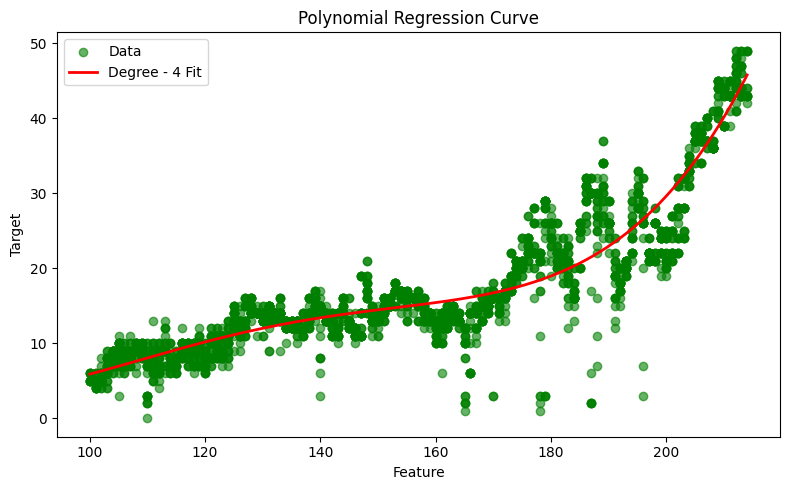

In [11]:
#Plot ( works well when X has a single feature)
if x.shape[1] == 1:
    x_range = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
    x_range_poly = poly_features.transform(x_range)
    y_range_pred = Powei.predict(x_range_poly)
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color = 'green', alpha=0.6, label='Data')
    plt.plot(x_range, y_range_pred, color='red', lw=2, label=f'Degree - {degree} Fit')
    plt.xlabel('Feature')
    plt.ylabel('Target')
    plt.title('Polynomial Regression Curve')
    plt.legend()
    plt.tight_layout()
    plt.savefig('Polynomial_Regression_Fit.png', dpi=150)
    plt.show()



In [22]:
Powei.predict(poly_features.transform([[214]]))

array([45.76895496])